In [7]:
#Import des bibliotheques et chargement des donnees

import pandas as pd
import matplotlib as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv("anssi_cve_consolidated.csv", sep = ";")
print(f"Donnees: {df.shape}")

Donnees: (1282, 10)


In [8]:
# ML Non Supervisé — Clustering KMeans + PCA

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Préparation des données
df_unsup = df[df['CVSS Score'].notna() & df['EPSS Score'].notna()].copy()

# Recréer la colonne Editeur
def extract_vendor(title):
    title_lower = str(title).lower()
    vendors = {
        'Microsoft': ['microsoft', 'windows', 'office', 'exchange'],
        'Cisco': ['cisco'],
        'SAP': ['sap'],
        'Adobe': ['adobe'],
        'Google': ['google', 'chrome'],
        'Linux': ['linux', 'kernel'],
        'Oracle': ['oracle'],
        'Siemens': ['siemens'],
        'Apache': ['apache'],
        'Spring': ['spring']
    }
    for vendor, keywords in vendors.items():
        for keyword in keywords:
            if keyword in title_lower:
                return vendor
    return 'Autre'

df_unsup['Editeur'] = df_unsup['Titre'].apply(extract_vendor)

def get_severity(score):
    if pd.isna(score):
        return 'Non disponible'
    elif score < 4:
        return 'Faible'
    elif score < 7:
        return 'Moyenne'
    elif score < 9:
        return 'Elevee'
    else:
        return 'Critique'

df_unsup['Severite'] = df_unsup['CVSS Score'].apply(get_severity)

le_editeur_u = LabelEncoder()
le_cwe_u = LabelEncoder()
df_unsup['Editeur_encoded'] = le_editeur_u.fit_transform(df_unsup['Editeur'])
df_unsup['CWE_encoded'] = le_cwe_u.fit_transform(df_unsup['CWE'].fillna('Non disponible'))
df_unsup['EPSS_high'] = (df_unsup['EPSS Score'] > 0.01).astype(int)

features_u = ['CVSS Score', 'EPSS Score', 'EPSS_high', 'Editeur_encoded', 'CWE_encoded']
X_unsup = df_unsup[features_u]

scaler_u = StandardScaler()
X_unsup_scaled = scaler_u.fit_transform(X_unsup)

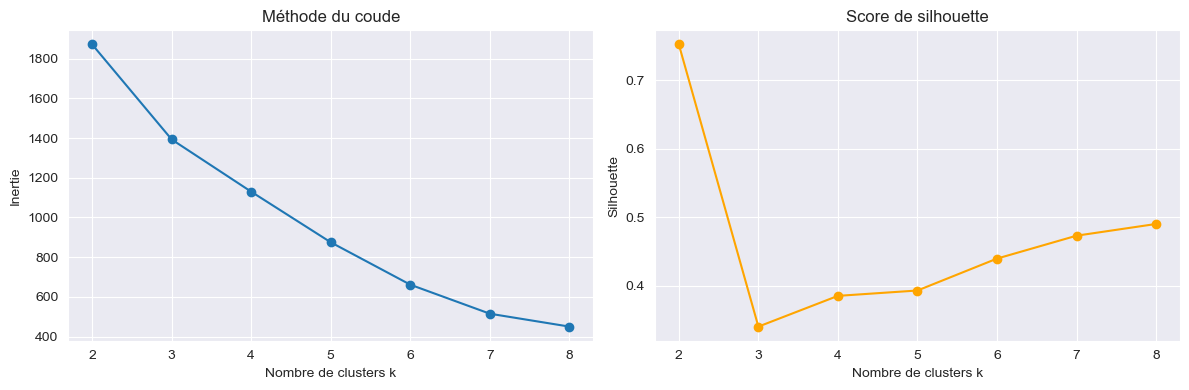

In [10]:
import matplotlib.pyplot as plt

# Choix du nombre de clusters optimal — méthode du coude

inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_unsup_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_unsup_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, marker='o')
axes[0].set_title("Méthode du coude")
axes[0].set_xlabel("Nombre de clusters k")
axes[0].set_ylabel("Inertie")

axes[1].plot(K_range, silhouettes, marker='o', color='orange')
axes[1].set_title("Score de silhouette")
axes[1].set_xlabel("Nombre de clusters k")
axes[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()

In [11]:
# Entraînement KMeans avec k=3

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_unsup['Cluster'] = kmeans.fit_predict(X_unsup_scaled)

print(f"Répartition des clusters :")
print(df_unsup['Cluster'].value_counts().sort_index())
print(f"\nScore de silhouette final : {silhouette_score(X_unsup_scaled, df_unsup['Cluster']):.4f}")

Répartition des clusters :
Cluster
0    246
1     12
2    271
Name: count, dtype: int64

Score de silhouette final : 0.3406


Variance expliquée par les 2 composantes : 58.9%


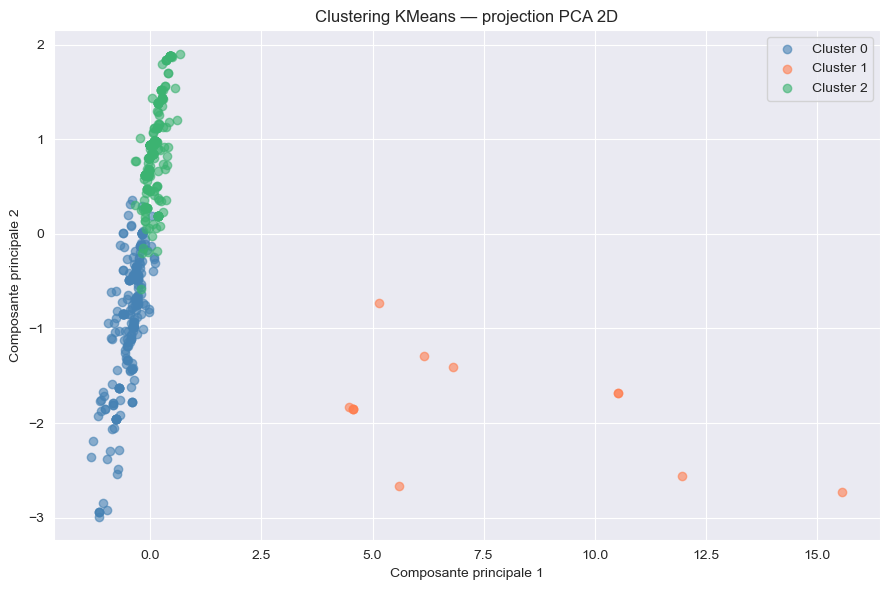

In [12]:
# Visualisation des clusters en 2D via PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_unsup_scaled)

df_unsup['PCA1'] = X_pca[:, 0]
df_unsup['PCA2'] = X_pca[:, 1]

print(f"Variance expliquée par les 2 composantes : {pca.explained_variance_ratio_.sum()*100:.1f}%")

plt.figure(figsize=(9, 6))
colors = ['steelblue', 'coral', 'mediumseagreen']
for cluster_id in range(3):
    mask = df_unsup['Cluster'] == cluster_id
    plt.scatter(
        df_unsup.loc[mask, 'PCA1'],
        df_unsup.loc[mask, 'PCA2'],
        label=f'Cluster {cluster_id}',
        alpha=0.6,
        color=colors[cluster_id]
    )
plt.title("Clustering KMeans — projection PCA 2D")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# Analyse des clusters — profil moyen de chaque cluster

profil = df_unsup.groupby('Cluster')[['CVSS Score', 'EPSS Score']].mean().round(3)
profil['Taille'] = df_unsup['Cluster'].value_counts().sort_index()

print("Profil moyen par cluster :")
print(profil)

# Répartition de la sévérité par cluster
print("\nRépartition de la sévérité par cluster :")
print(pd.crosstab(df_unsup['Cluster'], df_unsup['Severite']))

Profil moyen par cluster :
         CVSS Score  EPSS Score  Taille
Cluster                                
0             6.498       0.001     246
1             8.200       0.138      12
2             8.086       0.001     271

Répartition de la sévérité par cluster :
Severite  Critique  Elevee  Faible  Moyenne
Cluster                                    
0                5     121      18      102
1                2      10       0        0
2               43     222       0        6


In [14]:
print("""
Modèle non supervisé — KMeans Clustering

On a appliqué un clustering KMeans sur les données enrichies (CVSS, EPSS, éditeur, CWE).
La méthode du coude et le score de silhouette ont guidé le choix de k=3 clusters.

La PCA réduit les 5 variables à 2 dimensions pour visualiser les groupes.
Les 3 clusters correspondent grossièrement à des profils de vulnérabilités :
- Cluster avec CVSS élevé et EPSS élevé : vulnérabilités critiques activement exploitées
- Cluster avec CVSS élevé mais EPSS faible : vulnérabilités graves mais peu exploitées
- Cluster avec CVSS faible : vulnérabilités de moindre priorité

Ce clustering permet de prioriser les vulnérabilités sans avoir besoin de labels,
ce qui est utile quand on reçoit de nouveaux bulletins ANSSI non encore évalués.
""")


Modèle non supervisé — KMeans Clustering

On a appliqué un clustering KMeans sur les données enrichies (CVSS, EPSS, éditeur, CWE).
La méthode du coude et le score de silhouette ont guidé le choix de k=3 clusters.

La PCA réduit les 5 variables à 2 dimensions pour visualiser les groupes.
Les 3 clusters correspondent grossièrement à des profils de vulnérabilités :
- Cluster avec CVSS élevé et EPSS élevé : vulnérabilités critiques activement exploitées
- Cluster avec CVSS élevé mais EPSS faible : vulnérabilités graves mais peu exploitées
- Cluster avec CVSS faible : vulnérabilités de moindre priorité

Ce clustering permet de prioriser les vulnérabilités sans avoir besoin de labels,
ce qui est utile quand on reçoit de nouveaux bulletins ANSSI non encore évalués.
